In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import ipywidgets as widgets
from IPython.display import display, clear_output


# Путь к данным
DATA_PATH = "/home/makarov/PycharmProjects/course_work_big_data/data/ecommerce_customer_data_large.csv"

In [42]:
# 1. Загрузка данных
def load_data():
    try:
        df = pd.read_csv(DATA_PATH)
        print("Данные успешно загружены!")
        return df
    except FileNotFoundError:
        print(f"Файл по пути {DATA_PATH} не найден.")
        return None

In [43]:
# 2. Анализ данных
def analyze_data(df):
    print("Информация о данных:")
    print(df.info())
    print("\nОписание данных:")
    print(df.describe())
    print("\nПроверка на пропущенные значения:")
    print(df.isnull().sum())

    # Визуализация распределений
    for column in df.select_dtypes(include=np.number).columns:
        sns.histplot(df[column], kde=True)
        plt.title(f"Распределение {column}")
        plt.show()

In [44]:
# 3. Очистка и предобработка данных
def preprocess_data(df):
    # Удаление строк с пропусками
    df = df.dropna().reset_index(drop=True)  # Сброс индексов для согласованности

    # Преобразование категориальных данных
    label_encoders = {}
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df.loc[:, col] = le.fit_transform(df[col])  # Используем .loc для избежания предупреждений
        label_encoders[col] = le
    
    # Масштабирование
    scaler = StandardScaler()
    numeric_columns = df.select_dtypes(include=np.number).columns

    # Преобразование столбцов в float перед масштабированием
    df[numeric_columns] = df[numeric_columns].astype(float)
    
    # Масштабирование и замена значений
    df.loc[:, numeric_columns] = scaler.fit_transform(df[numeric_columns])
    
    return df, label_encoders

In [45]:
# 4. Кластеризация и прогнозирование
def cluster_and_predict(df):
    # Кластеризация
    kmeans = KMeans(n_clusters=4, random_state=42)
    df.loc[:, 'Cluster'] = kmeans.fit_predict(df)  # Используем .loc[]
    
    # Разделение данных
    X = df.drop(columns='Cluster')
    y = df['Cluster']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    # Прогнозирование
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("Отчет классификации:")
    print(classification_report(y_test, y_pred))
    
    # Матрица ошибок
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок')
    plt.show()
    
    return df

In [46]:
# 5. Визуализация кластеров
def visualize_clusters(df):
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(df.drop(columns='Cluster'))
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['Cluster'], palette='Set1')
    plt.title('Кластеры покупателей (PCA)')
    plt.show()

In [47]:
# 6. Генерация отчета
def generate_report(df):
    clusters_summary = df.groupby('Cluster').mean()
    print("Сводка по кластерам:")
    print(clusters_summary)

In [48]:
# 7. Фильтрация по целевой аудитории
def filter_audience(df):
    # Виджеты для ввода параметров целевой аудитории
    age_min = widgets.IntText(value=18, description='Возраст от:')
    age_max = widgets.IntText(value=50, description='Возраст до:')
    income_min = widgets.FloatText(value=20000, description='Доход от:')
    income_max = widgets.FloatText(value=100000, description='Доход до:')
    filter_button = widgets.Button(description="Фильтровать")

    # Контейнер для вывода результатов
    output = widgets.Output()

    display(age_min, age_max, income_min, income_max, filter_button, output)

    def on_filter_click(_):
        # Очищаем предыдущий вывод
        with output:
            clear_output()
            # Применение фильтров
            filtered_df = df[
                (df['Age'] >= age_min.value) &
                (df['Age'] <= age_max.value) &
                (df['Income'] >= income_min.value) &
                (df['Income'] <= income_max.value)
            ]
            print(f"Найдено {len(filtered_df)} записей соответствующих фильтру.")
            display(filtered_df.head())
            # Рекомендация продуктов
            recommend_products(filtered_df, output)

    # Привязываем обработчик событий к кнопке
    filter_button.on_click(on_filter_click)


In [49]:
# 8. Рекомендация продуктов
def recommend_products(filtered_df, output):
    with output:
        # Пример: выбираем топ-5 популярных продуктов для выбранной аудитории
        if 'Product' in filtered_df.columns:
            product_recommendations = (
                filtered_df['Product']
                .value_counts()
                .head(5)
                .index.tolist()
            )
            print("Рекомендуемые продукты для данной аудитории:")
            for i, product in enumerate(product_recommendations, start=1):
                print(f"{i}. {product}")
        else:
            print("Столбец 'Product' не найден в данных. Проверьте структуру данных.")


In [50]:
# Полный процесс с фильтрацией и рекомендацией
def full_analysis():
    print("Анализ данных...")
    analyze_data(df)
    print("Очистка данных...")
    clean_data, encoders = preprocess_data(df)
    print("Кластеризация и прогнозирование...")
    clustered_data = cluster_and_predict(clean_data)
    print("Фильтрация аудитории и рекомендации...")
    filter_audience(clustered_data)

Анализ данных...
Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24

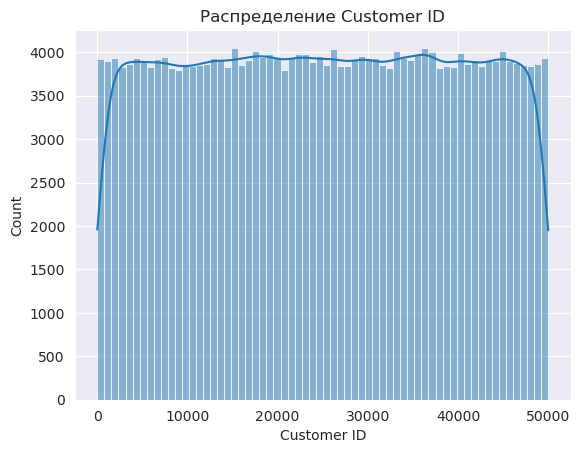

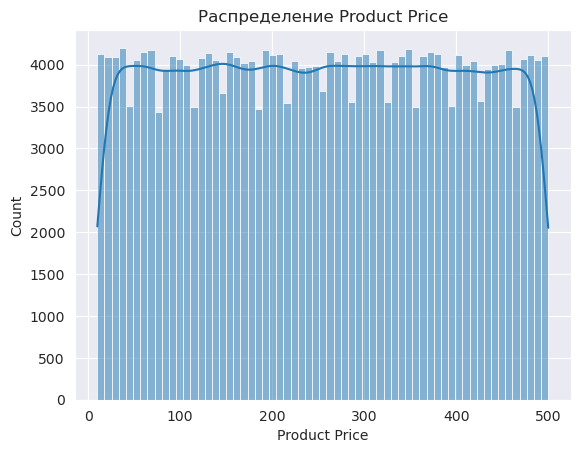

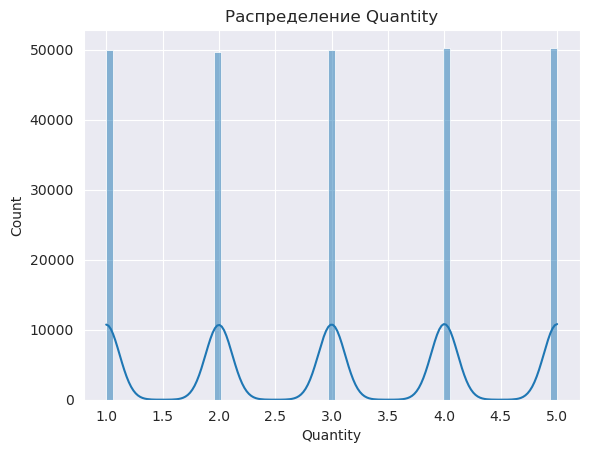

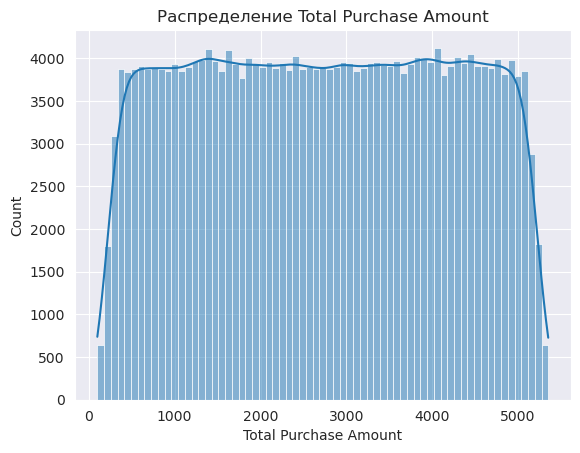

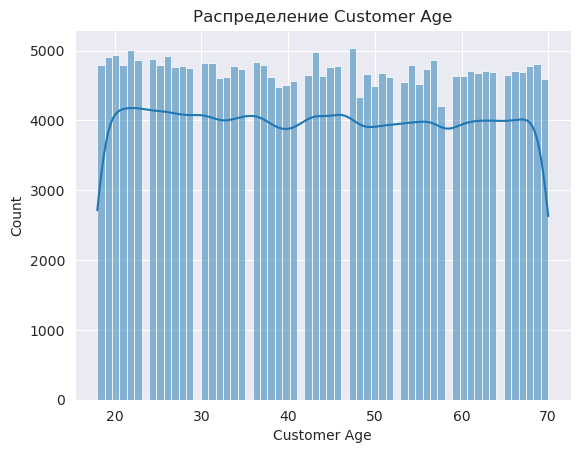

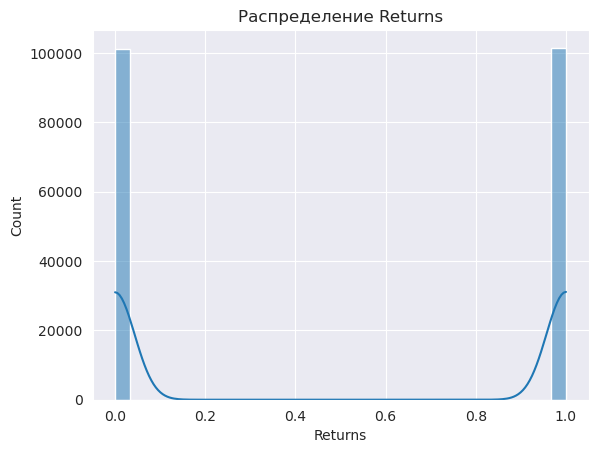

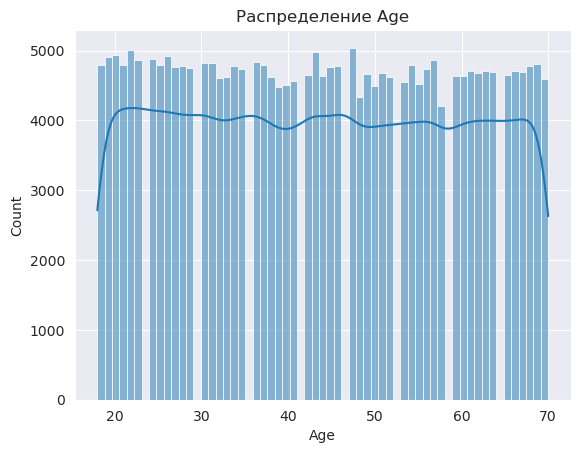

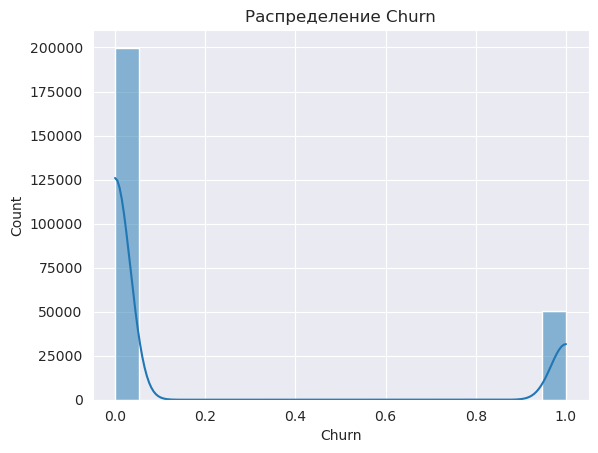

Очистка данных...
Кластеризация и прогнозирование...
Отчет классификации:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15135
           1       1.00      1.00      1.00     15296
           2       1.00      1.00      1.00     15098
           3       1.00      1.00      1.00     15257

    accuracy                           1.00     60786
   macro avg       1.00      1.00      1.00     60786
weighted avg       1.00      1.00      1.00     60786



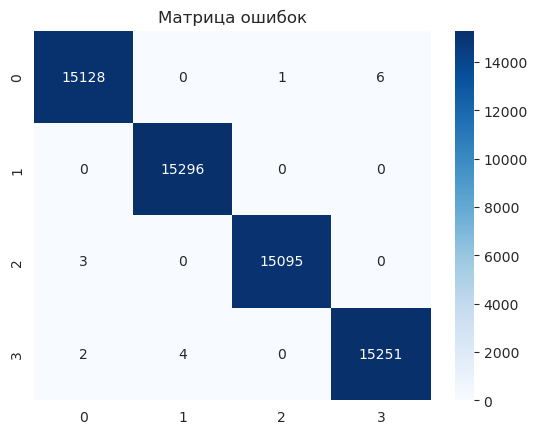

Фильтрация аудитории и рекомендации...


IntText(value=18, description='Возраст от:')

IntText(value=50, description='Возраст до:')

FloatText(value=20000.0, description='Доход от:')

FloatText(value=100000.0, description='Доход до:')

Button(description='Фильтровать', style=ButtonStyle())

Output()

In [51]:
# Запуск анализа
if __name__ == "__main__":
    full_analysis()
